# Comparative reporting

Step-by-step notebook for comparing flat evaluation runs with `soda_mmqc.reporting`.

We build one comparison view at a time. We load **both models** up front; later steps will compare models as well as prompts.

Views so far: **per-run dashboard** (`build_dashboard`), **Structure (Layer S)**, **Applicability (Layer 1)**, and **Matching (Layer 2)** — each with prompt/model multiplots and culprit tables.

| | |
|--|--|
| **Check** | `micrograph-scale-bar` |
| **Models** | `gpt-5-mini-2025-08-07`, `gpt-5` |
| **Prompts** | `prompt.1`, `prompt.2`, `prompt.3` |

Run with the project venv (`uv sync`) from the repo root.

## Setup

In [1]:
from __future__ import annotations

import pandas as pd

from soda_mmqc.reporting import (
    build_dashboard,
    load_flat_runs,
    plot_comparison_layer1,
    plot_comparison_layer2_binary,
    plot_comparison_layer2_graded,
    plot_comparison_layer_s,
    show_instance_context,
    show_layer1_errors,
    show_layer2_errors,
    show_table,
    summarize_runs,
)
from soda_mmqc.reporting.styles import (
    LAYER1_TITLE,
    LAYER2_BINARY_TITLE,
    LAYER2_GRADED_TITLE,
    LAYER_S_TITLE,
)

CHECKLIST = "fig-checklist"
CHECK = "micrograph-scale-bar"
MODELS = ["gpt-5-mini-2025-08-07", "gpt-5"]
PROMPTS = ["prompt.1", "prompt.2", "prompt.3"]

# Selectors — change these to focus each comparison view
MODEL = "gpt-5"
PROMPT = "prompt.2"  # scale-bar applicability outliers on this check
CULPRIT_LAYER1 = "spurious_applicable"  # initial culprit-table filter

LAYER_S_FIG_HEIGHT = 300
LAYER_S_FIG_WIDTH = 500
LAYER1_FIG_HEIGHT = 700
LAYER1_FIG_WIDTH = 1200
LAYER2_FIG_HEIGHT = 500
LAYER2_FIG_WIDTH = 1200
DASHBOARD_FIG_HEIGHT = 300
DASHBOARD_FIG_WIDTH = 1200


2026-06-15 15:53:12 - INFO - ✅ OpenAI API provider configured


### Load runs and summarize

Load all `(model, prompt)` pairs we will need for prompt and model contrasts. One `RunSummary` per pair. Layer S counts live in `by_list_row_counts` (keyed by predictive list, usually `outputs`).

In [2]:
runs = load_flat_runs(
    CHECKLIST,
    CHECK,
    models=MODELS,
    prompts=PROMPTS,
)
summaries = summarize_runs(runs)

pd.DataFrame(
    [
        {
            "model": run.model,
            "prompt": run.prompt,
            "records": len(run.records),
            "by_list_keys": ", ".join(
                summaries[run.model, run.prompt].by_list_keys
            ),
        }
        for run in runs
    ]
)

,model,prompt,records,by_list_keys
0,gpt-5-mini-2025-08-07,prompt.1,14,outputs
1,gpt-5-mini-2025-08-07,prompt.2,14,outputs
2,gpt-5-mini-2025-08-07,prompt.3,14,outputs
3,gpt-5,prompt.1,14,outputs
4,gpt-5,prompt.2,14,outputs
5,gpt-5,prompt.3,14,outputs


## Per-run dashboard (`build_dashboard`)

Single four-panel Plotly figure for one `(MODEL, PROMPT)` pair: Layer S counts, then Layer 1 / Layer 2 binary / Layer 2 graded stacked bars by field.

Use this as a quick snapshot before the comparison grids below. It does **not** overlay prompts or models — see whether that one-glance view is still worth keeping alongside the step-by-step sections.

In [3]:
(
    build_dashboard(summaries[MODEL, PROMPT])
    .update_layout(
        width=DASHBOARD_FIG_WIDTH,
        height=500,
        autosize=True,
        margin=dict(l=40, r=20, t=50, b=40),
    )
)

## Structural reporting

Reporting whether the lists of objects, ie. the panels, are correct, missing or spurious on this check.

In [4]:
fig_layer_s = plot_comparison_layer_s(
    summaries,
    compare="prompt",
    model=MODEL,
)
if fig_layer_s is None:
    print(f"No {LAYER_S_TITLE} data for model={MODEL}")
else:
    fig_layer_s.update_layout(
        height=LAYER_S_FIG_HEIGHT,
        width=LAYER_S_FIG_WIDTH,
        autosize=True,
        margin=dict(l=40, r=20, t=50, b=40),
    )
    fig_layer_s.show()

## Applicability reporting (Layer 1)

Per leaf field: stacked applicability outcomes. One subplot per field; prompts or models on the x-axis within each panel.

### Comparing prompts

Subplot grid for `MODEL` (default `gpt-5`): three stacked bars per panel (one per prompt, distinguished by **opacity**).

In [5]:
fig_layer1_prompt = plot_comparison_layer1(
    summaries,
    compare="prompt",
    model=MODEL,
)
fig_layer1_prompt.update_layout(
    height=LAYER1_FIG_HEIGHT,
    width=LAYER1_FIG_WIDTH,
    autosize=True,
)
fig_layer1_prompt.show()

### Comparing models

Same layout for `PROMPT` (default `prompt.2`). Models on the x-axis; distinguished by **bar hatching**.

In [6]:
PROMPT

'prompt.2'

In [7]:
fig_layer1_model = plot_comparison_layer1(
    summaries,
    compare="model",
    prompt=PROMPT,
)
fig_layer1_model.update_layout(
    height=LAYER1_FIG_HEIGHT,
    width=LAYER1_FIG_WIDTH,
    autosize=True,
)
fig_layer1_model.show()

### Applicability culprits

Instance table for one `(MODEL, PROMPT)` pair. Pre-filtered to `CULPRIT_LAYER1`; adjust filters in the table footer.

In [8]:
summary_selected = summaries[MODEL, PROMPT]

show_layer1_errors(
    summary_selected,
    layer1=CULPRIT_LAYER1,
    caption=(
        f"Layer 1 culprits — {CHECK} / {MODEL} / {PROMPT} "
        f"(initial filter: {CULPRIT_LAYER1})"
    ),
)

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


## Matching reporting (Layer 2)

This check mixes **binary** fields (e.g. `micrograph`, `scale_bar_*`) and **graded** string fields (e.g. `from_the_caption`). One subplot per field in each chart.

### Matching-binary — comparing prompts

Subplot grid for `MODEL`: stacked TP/TN/FP/FN; prompts distinguished by **opacity**.

In [9]:
fig_layer2_binary_prompt = plot_comparison_layer2_binary(
    summaries,
    compare="prompt",
    model=MODEL,
)
fig_layer2_binary_prompt.update_layout(
    height=LAYER2_FIG_HEIGHT,
    width=LAYER2_FIG_WIDTH,
    autosize=True,
)
fig_layer2_binary_prompt.show()

### Matching-binary — comparing models

Same layout for `PROMPT`; models distinguished by **bar hatching**.

In [10]:
fig_layer2_binary_model = plot_comparison_layer2_binary(
    summaries,
    compare="model",
    prompt=PROMPT,
)
fig_layer2_binary_model.update_layout(
    height=LAYER2_FIG_HEIGHT,
    width=LAYER2_FIG_WIDTH,
    autosize=True,
)
fig_layer2_binary_model.show()

### Matching-graded — comparing prompts

Graded string fields only (`match` / `mismatch` stacks).

In [11]:
fig_layer2_graded_prompt = plot_comparison_layer2_graded(
    summaries,
    compare="prompt",
    model=MODEL,
)
fig_layer2_graded_prompt.update_layout(
    height=LAYER2_FIG_HEIGHT,
    width=LAYER2_FIG_WIDTH,
    autosize=True,
)
fig_layer2_graded_prompt.show()

### Matching-graded — comparing models

In [12]:
fig_layer2_graded_model = plot_comparison_layer2_graded(
    summaries,
    compare="model",
    prompt=PROMPT,
)
fig_layer2_graded_model.update_layout(
    height=LAYER2_FIG_HEIGHT,
    width=LAYER2_FIG_WIDTH,
    autosize=True,
)
fig_layer2_graded_model.show()

### Matching culprits

Instance-level layer-1 outliers and layer-2 errors for one `(MODEL, PROMPT)` pair.

In [13]:
show_layer2_errors(
    summaries[MODEL, PROMPT],
    caption=f"Layer 2 culprits — {CHECK} / {MODEL} / {PROMPT}",
)

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


## Instance drill-down

Pick a row from a culprit table (`source`, `path`, `leaf_property`) — or set only `source` to see the full model output for that example call (caption, figure, gold vs pred JSON).

**Example context** — `fig-checklist` / `micrograph-scale-bar` / `gpt-5` / `prompt.2`  
`source=10.1038_s44318-026-00715-1/content/4`

**Caption**  
Figure 4: PacL proteins collaborate to assemble multi-metal efflux machineries.(A) Bipartite split-GFP assay in M. smegmatis expressing a PacL1-GFP11 fusion protein along with GFP1-10 (control) or the indicated proteins fused to GFP11 (first protein) or GFP1-10 (second protein). Fluorescence was recorded by flow cytometry and expressed as the percentage of GFP-positive cells. Data were presented as mean ± SEM from biological replicates, represented by green dots. (B) Epifluorescence microscopy images of fixed M. tuberculosis strain carrying a genome-integrative vector expressing the indicated M. tuberculosis genes under the control of their native promoter, cultivated in the absence or presence of the indicated metals (100 µM ZnSO4 and/or 10 µM CdSO4). The right panel shows colocalization of mTurquoise and mVenus fluorescent signals along the red line in the overlay image. (C, D) Mean fluorescence intensity (gray values) quantified in ImageJ from 8-bit grayscale images of individual cells from the same genetic background and growth conditions as in (B). Results are presented as mean ± SEM from individual cells, represented by yellow or blue dots. (E) Epifluorescence microscopy images of fixed M. smegmatis strains carrying a genome-integrative vector expressing the indicated M. tuberculosis genes under the control of their native promoter, cultivated with 100 nM CdSO4. The right panel shows colocalization of mTurquoise and mVenus fluorescent signals along the red line in the overlay image. (F–H) Bipartite split-GFP assay in M. smegmatis expressing a PacL1-GFP11 fusion protein along with GFP1-10 (control) or the indicated proteins fused to GFP11 (first protein) or GFP1-10 (second protein). Fluorescence was recorded by flow cytometry and expressed as the percentage of GFP-positive cells. Data were presented as mean ± SEM from biological replicates, represented by green dots. (I) Cadmium (CdSO4) sensitivity of M. smegmatis strains harboring a genome-integrative vector expressing the indicated M. tuberculosis pacL-ctp genes under the control of an ATC-inducible promoter, assessed by disk diffusion assay in the presence of the inducer. Inhibition zone diameters normalized to the empty vector control (tet-empty) are shown as mean ± SEM from biological replicates, with individual values indicated by gray dots. (J) Epifluorescence microscopy images of live M. smegmatis strains carrying a genome-integrative vector expressing the indicated M. tuberculosis genes under the control of the indicated promoters, cultivated without or with 50 nM anhydrotetracycline (ATC). (K, L) Mean fluorescence intensity (gray values) quantified in ImageJ from 8-bit grayscale images of individual cells from the same genetic background and growth conditions as in (J). Results are presented as mean ± SEM from individual cells, represented by yellow or blue dots. (M) Bacterial growth of the indicated M. tuberculosis strains in the absence or presence of 10 µM CdSO4, evaluated by turbidity measurements (McFarland units). Data represent mean ± SEM from biological triplicates. For statistical analysis, (A, C, D, F–I) one-way ANOVA with a Dunnett post-test or (K, L) an unpaired t-test were performed. Statistical analyses were conducted on ln-transformed data for (A, C, D, F–H. Asterisks indicate statistically significant differences compared to the reference condition (control (A, F, G, H), PacL1mV (C), PacL2mT (D), empty vector (I)), or between conditions linked by a black line (F, K, L) (**P < 0.01; ****P < 0.0001). Exact p values and biological replicate numbers presented in this figure are reported in Table EV6. PacL2mT: PacL2-mTurquoise fusion; CtpGmV: CtpG-mVenus fusion; tet-: ATC-inducible promoter; pL1: pacL1 promoter; CtpAMBD, CtpCMBD, CtpGMBD, and CtpVMBD: N-terminal domain of CtpA, CtpC, CtpG, and CtpV encoding the predicted P-ATPase metal-binding domain.

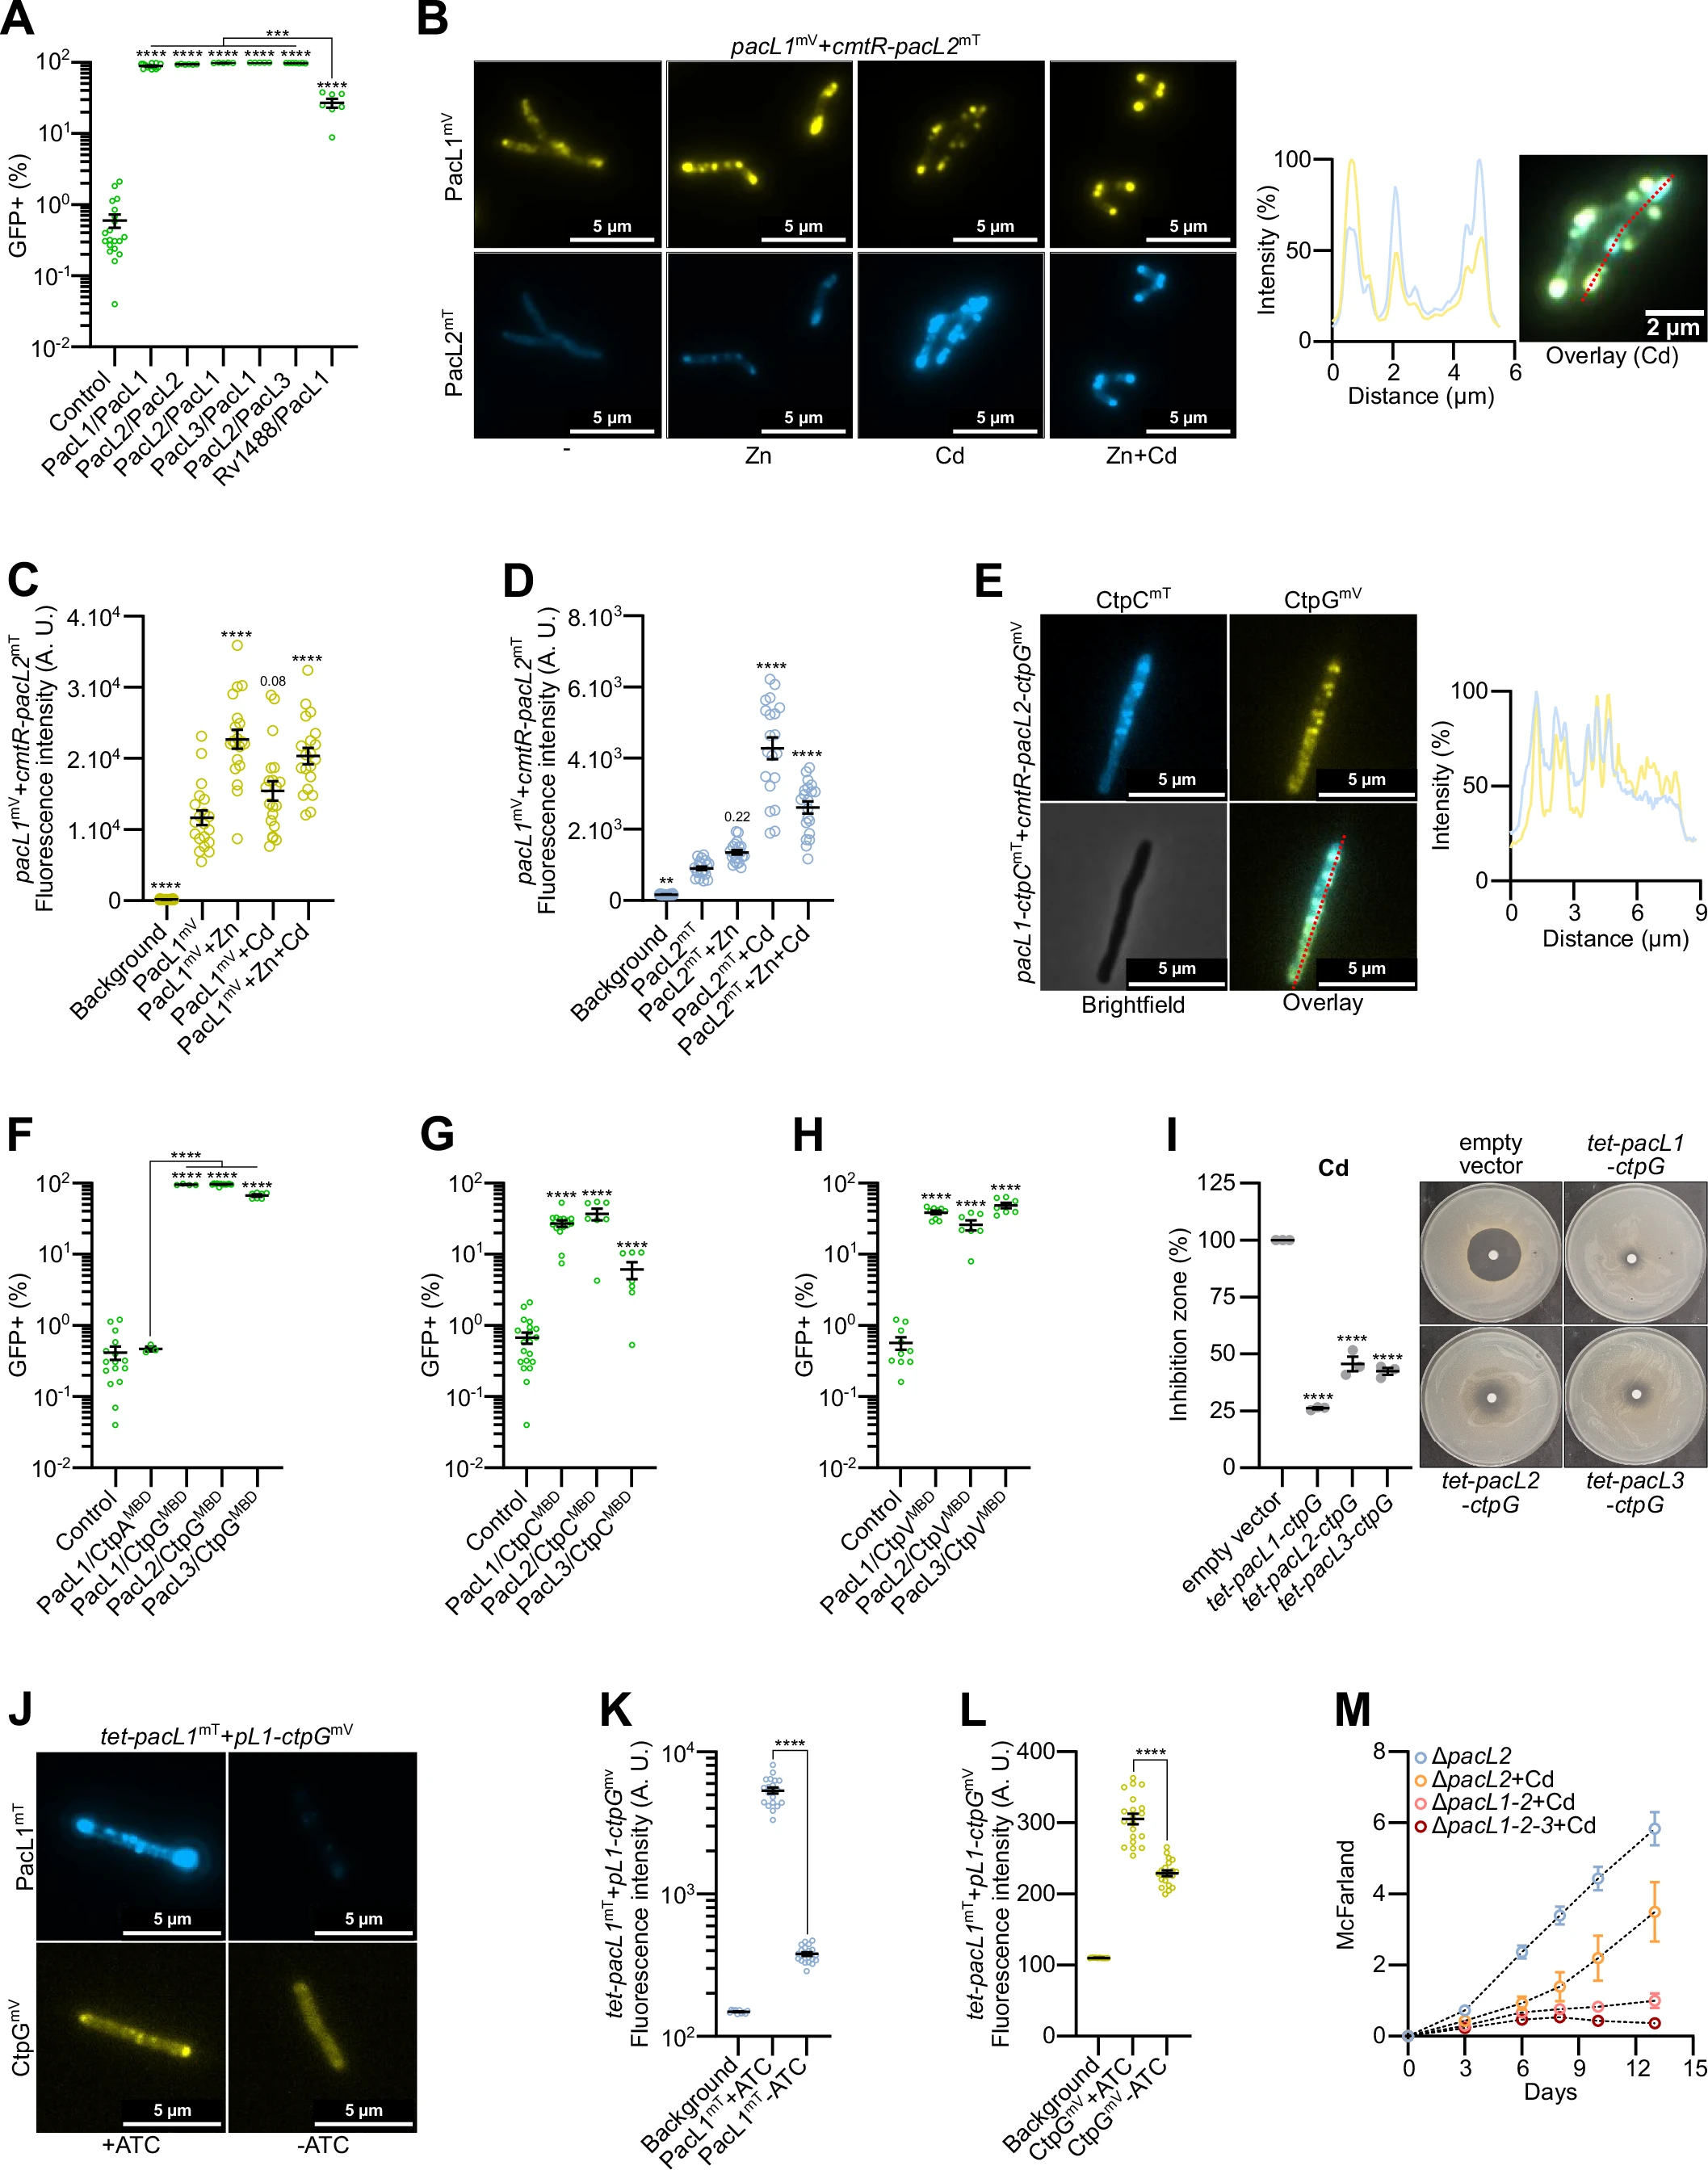

**Model output (gold vs pred)**

,gold,pred
0,"{\n ""outputs"": [\n {\n ""panel_label"":...","{\n ""outputs"": [\n {\n ""panel_label"":..."


**Example context** — `fig-checklist` / `micrograph-scale-bar` / `gpt-5` / `prompt.2`  
`source=10.1038_s44318-026-00715-1/content/4` · `steps=['outputs', 1, 'micrograph']`

**Caption**  
Figure 4: PacL proteins collaborate to assemble multi-metal efflux machineries.(A) Bipartite split-GFP assay in M. smegmatis expressing a PacL1-GFP11 fusion protein along with GFP1-10 (control) or the indicated proteins fused to GFP11 (first protein) or GFP1-10 (second protein). Fluorescence was recorded by flow cytometry and expressed as the percentage of GFP-positive cells. Data were presented as mean ± SEM from biological replicates, represented by green dots. (B) Epifluorescence microscopy images of fixed M. tuberculosis strain carrying a genome-integrative vector expressing the indicated M. tuberculosis genes under the control of their native promoter, cultivated in the absence or presence of the indicated metals (100 µM ZnSO4 and/or 10 µM CdSO4). The right panel shows colocalization of mTurquoise and mVenus fluorescent signals along the red line in the overlay image. (C, D) Mean fluorescence intensity (gray values) quantified in ImageJ from 8-bit grayscale images of individual cells from the same genetic background and growth conditions as in (B). Results are presented as mean ± SEM from individual cells, represented by yellow or blue dots. (E) Epifluorescence microscopy images of fixed M. smegmatis strains carrying a genome-integrative vector expressing the indicated M. tuberculosis genes under the control of their native promoter, cultivated with 100 nM CdSO4. The right panel shows colocalization of mTurquoise and mVenus fluorescent signals along the red line in the overlay image. (F–H) Bipartite split-GFP assay in M. smegmatis expressing a PacL1-GFP11 fusion protein along with GFP1-10 (control) or the indicated proteins fused to GFP11 (first protein) or GFP1-10 (second protein). Fluorescence was recorded by flow cytometry and expressed as the percentage of GFP-positive cells. Data were presented as mean ± SEM from biological replicates, represented by green dots. (I) Cadmium (CdSO4) sensitivity of M. smegmatis strains harboring a genome-integrative vector expressing the indicated M. tuberculosis pacL-ctp genes under the control of an ATC-inducible promoter, assessed by disk diffusion assay in the presence of the inducer. Inhibition zone diameters normalized to the empty vector control (tet-empty) are shown as mean ± SEM from biological replicates, with individual values indicated by gray dots. (J) Epifluorescence microscopy images of live M. smegmatis strains carrying a genome-integrative vector expressing the indicated M. tuberculosis genes under the control of the indicated promoters, cultivated without or with 50 nM anhydrotetracycline (ATC). (K, L) Mean fluorescence intensity (gray values) quantified in ImageJ from 8-bit grayscale images of individual cells from the same genetic background and growth conditions as in (J). Results are presented as mean ± SEM from individual cells, represented by yellow or blue dots. (M) Bacterial growth of the indicated M. tuberculosis strains in the absence or presence of 10 µM CdSO4, evaluated by turbidity measurements (McFarland units). Data represent mean ± SEM from biological triplicates. For statistical analysis, (A, C, D, F–I) one-way ANOVA with a Dunnett post-test or (K, L) an unpaired t-test were performed. Statistical analyses were conducted on ln-transformed data for (A, C, D, F–H. Asterisks indicate statistically significant differences compared to the reference condition (control (A, F, G, H), PacL1mV (C), PacL2mT (D), empty vector (I)), or between conditions linked by a black line (F, K, L) (**P < 0.01; ****P < 0.0001). Exact p values and biological replicate numbers presented in this figure are reported in Table EV6. PacL2mT: PacL2-mTurquoise fusion; CtpGmV: CtpG-mVenus fusion; tet-: ATC-inducible promoter; pL1: pacL1 promoter; CtpAMBD, CtpCMBD, CtpGMBD, and CtpVMBD: N-terminal domain of CtpA, CtpC, CtpG, and CtpV encoding the predicted P-ATPase metal-binding domain.

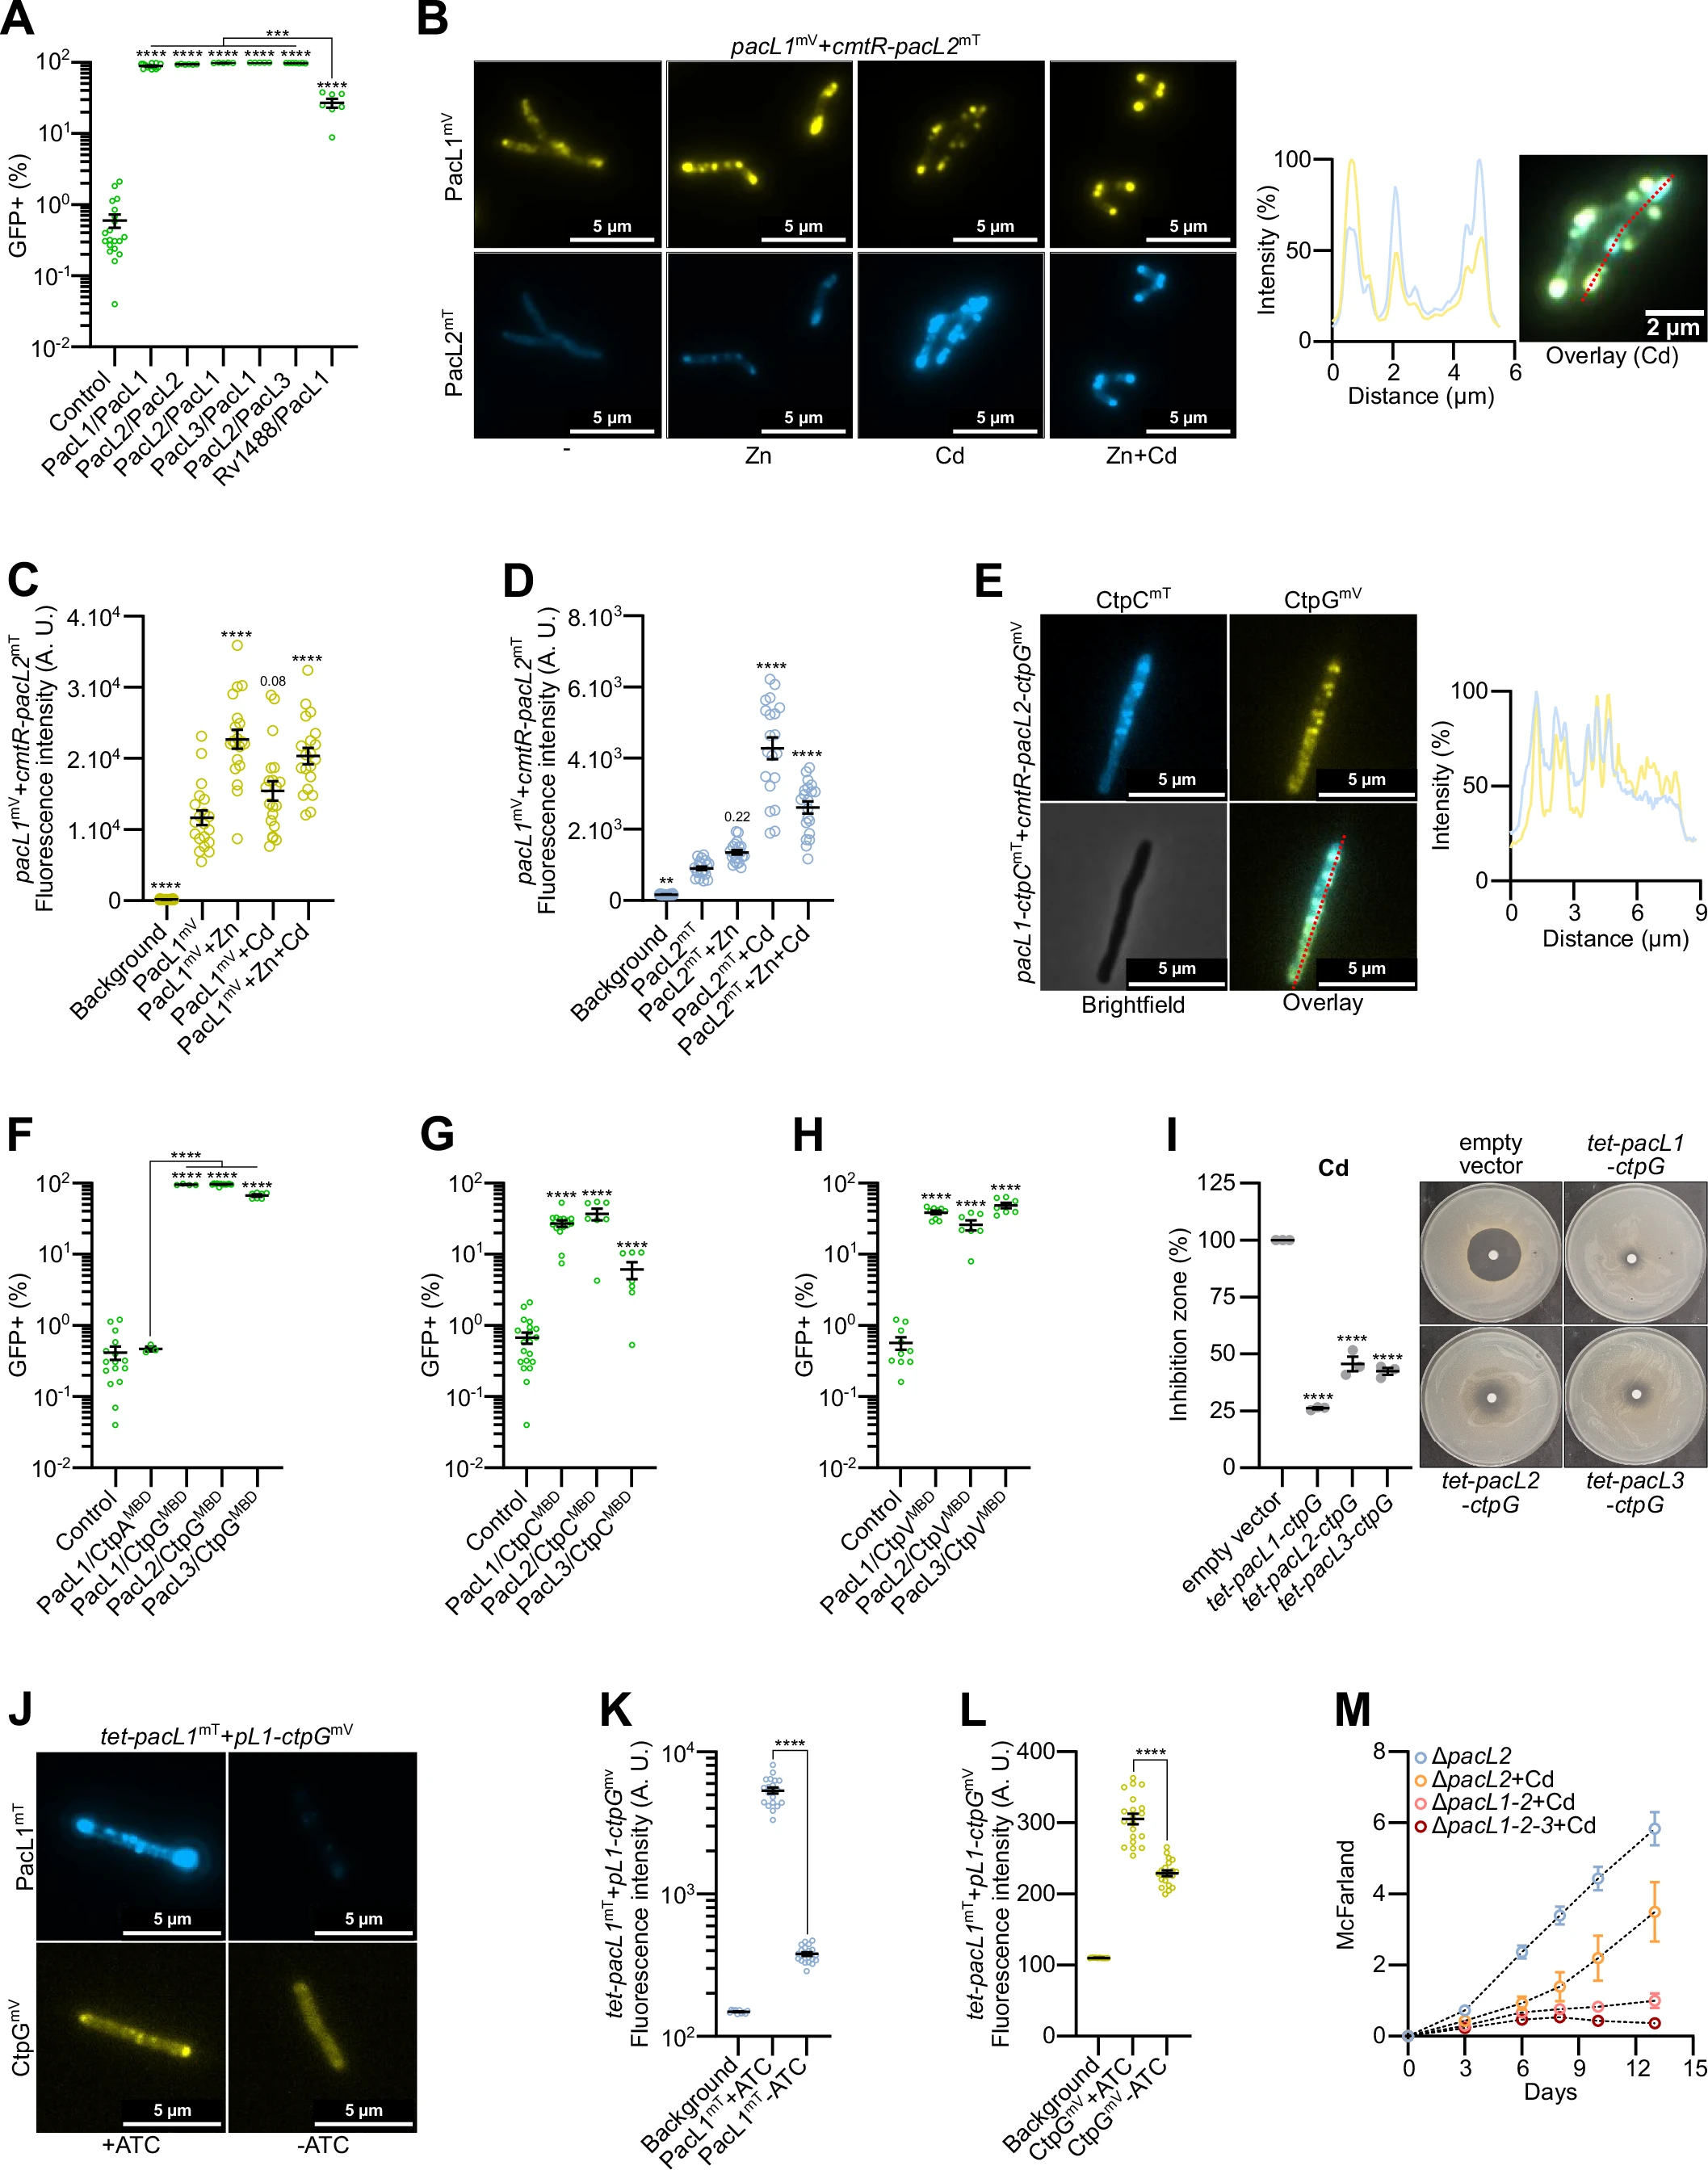

**At steps (gold vs pred)**

,gold,pred
0,'yes','yes'


**Parent row (gold vs pred)**

,gold row,pred row
0,"{\n ""panel_label"": ""B"",\n ""micrograph"": ""yes...","{\n ""panel_label"": ""B"",\n ""micrograph"": ""yes..."


**Leaf field `micrograph` (gold vs pred)**

,gold,pred
0,'yes','yes'


In [ ]:
# Selectors — copy from a culprit table row, or set only SOURCE for the full example
DRILL_SOURCE = "10.1038_s44318-026-00715-1/content/4"
DRILL_OBJECT_PATH = "outputs[1]"  # panel row within this source's outputs[]
DRILL_LEAF = "micrograph"

# Full source: caption, figure image, expected_output vs model_output
show_instance_context(summaries[MODEL, PROMPT], source=DRILL_SOURCE)

# Optional: one leaf field within a panel row
show_instance_context(
    summaries[MODEL, PROMPT],
    source=DRILL_SOURCE,
    object_path=DRILL_OBJECT_PATH,
    leaf=DRILL_LEAF,
)